# Dot design validation — RMSD (contact map similarity)

Computes and compares the Root Mean Squared Difference (RMSD) between
original and designed contact maps as predicted by Akita and Alpha Genome,
for dot designs with anchor distance 50 bins (`dot_d50`) across 8
cross-validation folds in mouse mESC (mm10).

Unlike `dots.ipynb` which scores a local window at the dot position,
RMSD measures the global contact map change induced by the design.
High Pearson R between Akita and Alpha Genome RMSD values indicates that
the overall contact map perturbation generalizes across models.

## Outline
1. Load Akita optimization results and RMSD scores
2. Load Alpha Genome RMSD scores
3. Merge and compare Akita vs. Alpha Genome RMSD

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pathlib import Path

## Paths and constants

In [2]:
BASE      = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita")
AKITA_DIR = BASE / "optimizations/dots/results/dot_d50"
ALPHA_DIR = BASE / "analysis/alpha_genome_validation/dot_design"
PLOTS_DIR = Path("./../plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

FOLDS      = range(8)
MERGE_KEYS = ["chrom", "centered_start", "centered_end"]

## 1. Load Akita optimization results and RMSD scores

Load per-fold TSVs containing Akita dot scores and RMSD values.
Compute dot score difference (edited − original) and flag successful
designs (positive diff indicates strengthened dot contact).

In [3]:
akita_dfs = []
for fold in FOLDS:
    path = AKITA_DIR / f"fold{fold}_dot_scd_akita_results.tsv"
    fold_df = pd.read_csv(path, sep="\t")
    fold_df["fold"] = fold
    akita_dfs.append(fold_df)

akita_df = pd.concat(akita_dfs, ignore_index=True)

# Successful = dot score increased after optimization
akita_df["dot_score_diff"]     = akita_df["dot15_edited"] - akita_df["dot15_orig"]
akita_df["optimization_success"] = akita_df["dot_score_diff"] > 0

print(f"Loaded {len(akita_df)} Akita rows across {akita_df['fold'].nunique()} folds")
print(f"Successful optimizations: {akita_df['optimization_success'].sum()} / {len(akita_df)}")

Loaded 355 Akita rows across 8 folds
Successful optimizations: 307 / 355


## 2. Load Alpha Genome RMSD scores

Load per-fold Alpha Genome results containing independently computed
RMSD values (`alpha_scd`) for the same loci.

In [4]:
alpha_dfs = []
for fold in FOLDS:
    path = ALPHA_DIR / f"fold{fold}_alphagenome_results.tsv"
    fold_df = pd.read_csv(path, sep="\t")
    alpha_dfs.append(fold_df)

alpha_df = pd.concat(alpha_dfs, ignore_index=True)
print(f"Loaded {len(alpha_df)} Alpha Genome rows across {alpha_df['fold'].nunique()} folds")

Loaded 355 Alpha Genome rows across 8 folds


## 3. Merge Akita and Alpha Genome results

Merge on genomic coordinates across folds. Analysis is restricted to
successfully optimized designs.

In [5]:
merged_df = akita_df.merge(
    alpha_df[MERGE_KEYS + ["fold", "alpha_scd"]],
    on=MERGE_KEYS,
    how="inner",
    validate="1:1",
)

n_dropped = len(akita_df) - len(merged_df)
if n_dropped:
    print(f"WARNING: {n_dropped} rows lost in merge — check for locus mismatches")

succ_df = merged_df[merged_df["optimization_success"]].copy()
print(f"Merged: {len(merged_df)} rows total, {len(succ_df)} successful")

Merged: 355 rows total, 307 successful


## 4. Akita vs. Alpha Genome RMSD comparison

Scatter plot of RMSD values from Akita (x-axis) vs. Alpha Genome (y-axis)
for all successful dot designs. Pearson R measures how consistently the
two models agree on the magnitude of contact map change induced by the
designed sequences.

Pearson R = 0.6965, p = 7.19e-46


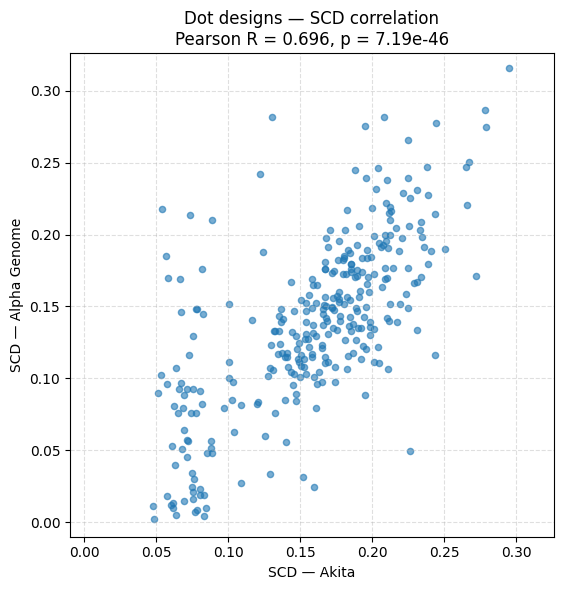

In [6]:
x = succ_df["akita_scd"].values
y = succ_df["alpha_scd"].values
r, p = pearsonr(x, y)
print(f"Pearson R = {r:.4f}, p = {p:.2e}")

lim = max(x.max(), y.max()) + 0.01

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, alpha=0.6, s=20)
ax.set_xlim(-0.01, lim)
ax.set_ylim(-0.01, lim)
ax.set_xlabel("SCD — Akita")
ax.set_ylabel("SCD — Alpha Genome")
ax.set_title(f"Dot designs — SCD correlation\nPearson R = {r:.3f}, p = {p:.2e}")
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "dot_scd_akita_vs_alphagenome.svg", format="svg")
plt.show()